This tutorial is an introduction to Graph Neural Networks (GNNs) using PyTorch Geometric. We will implement and compare several models for node classification.

First, let's install the packages needed in order to run our code.



In [1]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git


2.11.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.1/682.1 kB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


We will start with a few imports, followed by setting the random seed and selecting a device on which to run the experiments. If a GPU is available, we will opt for using CUDA.

In [2]:
import torch_geometric
from torch_geometric.loader import DataLoader
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score
import torch
from torch.nn import Linear, ReLU, Dropout, Sequential, ModuleList
import torch.nn.functional as F

seed = 39451
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# helper functions for visualization
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def plot_histogram(data, num_bins):
    plt.hist(data, bins=num_bins)
    plt.show()


def visualize(h, color):
    """This function provides a 2D projection of the data points using TSNE"""
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

def plot_performance_multiple_models(x_axis_values, performance_values):
    plt.plot(x_axis_values, performance_values)
    plt.xticks(x_axis_values)
    plt.show()

We will use the Cora dataset, available in PyTorch Geometric. This is a citation network, with nodes corresponding to papers and links being represented by citations. For each node, we have an associated class, representing the topic of the paper. This is a node classification problem, with 7 possible classes. Although the original graph is a directed one, the Planetoid class converts it into an undirected. For each node we have 1433 binary features - a vocabulary of 1433 words was created and the a value of 1 signifies that the word exists in the document. Let's analyze the dataset!

In [4]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Cora',  name="Cora")

def print_dataset_stats(dataset):
    print()
    print('======================')
    print(f'Dataset: {dataset}:')
    print(f'Number of graphs: {len(dataset)}')
    print(f'Number of training nodes: {sum(dataset[0].train_mask)}, number of validation nodes: {sum(dataset[0].val_mask)}, number of test nodes: {sum(dataset[0].test_mask)}')
    print(f'Total number of nodes in the graph: {len(dataset[0].x)}')
    print(f'Number of node features: {dataset.num_features}')
    print(f'Number of edge features: {dataset.num_edge_features}')
    print(f'Number of classes: {dataset.num_classes}')
    print(f'Is the graph undirected?', dataset[0].is_undirected())

print_dataset_stats(dataset)

Processing...
Done!



Dataset: Cora():
Number of graphs: 1
Number of training nodes: 140, number of validation nodes: 500, number of test nodes: 1000
Total number of nodes in the graph: 2708
Number of node features: 1433
Number of edge features: 0
Number of classes: 7
Is the graph undirected? True


A first question we may ask ourselves is if the graph is useful at all in the classification task. In order to check this, we will first train a MLP baseline which classifies the papers using only the node features.

In [5]:
class MLP(torch.nn.Module):
    def __init__(self, input_channels, hidden_channels,
                 num_outputs, num_layers, dropout_rate):
        super().__init__()

        layers = [
            Linear(input_channels, hidden_channels),
            ReLU(),
            Dropout(dropout_rate)
        ]

        for i in range(num_layers-2):
            layers.extend([
                Linear(hidden_channels, hidden_channels),
                ReLU(),
                Dropout(dropout_rate)
            ])

        layers.append(Linear(hidden_channels, num_outputs))

        self.network = Sequential(*layers)

    def forward(self, x, *args):
        return self.network(x)


In [6]:
# setting some hyper-parameters
# normally, these should be tuned using a validation set
# in our tutorial, we will fix these and compare multiple models using the same
# hyper-parameters
NUM_EPOCHS = 100 #@param {type:"integer"}
HIDDEN_CHANNELS = 128 #@param {type:"integer"}
LEARNING_RATE = 0.001 #@param {type:"number"}
# the batch size will be one because all nodes belong to the same graph
# (we have a transductive node classification task)
BATCH_SIZE = 1 #@param {type:"integer"}
DROPOUT_RATE = 0.1 #@param {type:"number"}

Next, we'll define some functions that will help us train and evaluate the models.

In [7]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))


def train_one_epoch(model, graph, train_mask, criterion, optimizer):
    # set model to train mode
    model.train()
    # move the node features and labels on the device
    data = graph.x.to(DEVICE)
    labels = graph.y.to(DEVICE)

    # zero out gradients in order to prevent accumulation from previous steps
    optimizer.zero_grad()

    if isinstance(model, MLP):
        out = model(data)
    else:
        # in our notebook, if the model is not a MLP, it must be a GNN
        edge_index = graph.edge_index.to(DEVICE)
        out = model(data, edge_index)

    # the graph contains training nodes, validation nodes, test nodes and unlabeled nodes
    # we compute the loss using ONLY the training nodes
    loss = criterion(out[train_mask], labels[train_mask])
    loss.backward()  # compute gradients
    optimizer.step()  # update parameters using the computed gradients

    return loss.item()


def evaluate(model, graph, eval_mask):
    # Set the model to eval mode
    model.eval()

    predicted_scores = []
    true_labels = []

    data = graph.x.to(DEVICE)
    labels = graph.y.to(DEVICE)

    if isinstance(model, MLP):
        out = model(data)
    else:
        edge_index = graph.edge_index.to(DEVICE)
        out = model(data, edge_index)

    # compute accuracy (it may be useful to compute other metrics too)
    acc = (out[eval_mask].argmax(dim=-1) == labels[eval_mask]).sum().float() / eval_mask.sum()

    return {'acc': acc}


def run_experiment(model, dataset):
    """function for running one experiment - training and evaluating the model """
    graph = dataset[0] # the dataset contains a single graph

    train_mask = graph.train_mask
    test_mask = graph.test_mask

    criterion = torch.nn.CrossEntropyLoss()  # define the classification loss
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)  # define the optimizer

    for epoch in range(NUM_EPOCHS):
        loss = train_one_epoch(model, graph, train_mask, criterion, optimizer)
        print(f'Epoch: {epoch}, Loss: {loss:.4f}')

    # evaluate the trained model on the test set
    test_results = evaluate(model, graph, test_mask)
    test_acc = test_results['acc']
    return test_acc

<IPython.core.display.Javascript object>

In [ ]:
print(DEVICE)

Let's train a MLP and check its performance.

In [10]:
num_layers = 4
model = MLP(dataset.num_features, HIDDEN_CHANNELS, dataset.num_classes, num_layers, DROPOUT_RATE)
# the model needs to be moved on the device
model.to(DEVICE)
test_acc = run_experiment(model, dataset)
print(f'Test accuracy: {test_acc}')

Epoch: 0, Loss: 1.9465
Epoch: 1, Loss: 1.9431
Epoch: 2, Loss: 1.9400
Epoch: 3, Loss: 1.9355
Epoch: 4, Loss: 1.9321
Epoch: 5, Loss: 1.9258
Epoch: 6, Loss: 1.9219
Epoch: 7, Loss: 1.9145
Epoch: 8, Loss: 1.9063
Epoch: 9, Loss: 1.8953
Epoch: 10, Loss: 1.8852
Epoch: 11, Loss: 1.8715
Epoch: 12, Loss: 1.8562
Epoch: 13, Loss: 1.8383
Epoch: 14, Loss: 1.8176
Epoch: 15, Loss: 1.7913
Epoch: 16, Loss: 1.7650
Epoch: 17, Loss: 1.7236
Epoch: 18, Loss: 1.6923
Epoch: 19, Loss: 1.6384
Epoch: 20, Loss: 1.5870
Epoch: 21, Loss: 1.5380
Epoch: 22, Loss: 1.4685
Epoch: 23, Loss: 1.3998
Epoch: 24, Loss: 1.3389
Epoch: 25, Loss: 1.2494
Epoch: 26, Loss: 1.1674
Epoch: 27, Loss: 1.0825
Epoch: 28, Loss: 1.0042
Epoch: 29, Loss: 0.8963
Epoch: 30, Loss: 0.8135
Epoch: 31, Loss: 0.7325
Epoch: 32, Loss: 0.6444
Epoch: 33, Loss: 0.5616
Epoch: 34, Loss: 0.4652
Epoch: 35, Loss: 0.4103
Epoch: 36, Loss: 0.3401
Epoch: 37, Loss: 0.2855
Epoch: 38, Loss: 0.2395
Epoch: 39, Loss: 0.1951
Epoch: 40, Loss: 0.1611
Epoch: 41, Loss: 0.1282
Ep

Now, let's see if by using also the graph information, the performance can be improved. We'll define a GNN using GCN layers. Our GNN will receive the number of input and output channels (needed in order to define the layers) and the number of GCN layers. Additionally, let's also add Dropout layers. GCN is already implemented in PyTorch Geometric, you can find its documentation [here](https://pytorch-geometric.readthedocs.io/en/2.6.0/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv ).

In [11]:
from torch_geometric.nn import GCNConv, MessagePassing

class GNN(torch.nn.Module):
    def __init__(self, input_channels, hidden_channels,
                 num_outputs, num_layers, dropout_rate, residual=False):
        super().__init__()
        self.layers = ModuleList()

        self.layers.extend([
            Linear(input_channels, hidden_channels),
            ReLU(),
            Dropout(dropout_rate)
        ])

        for _ in range(num_layers):
            self.layers.extend([
                GCNConv(hidden_channels, hidden_channels),
                ReLU(),
                Dropout(dropout_rate)
            ])

        self.layers.append(Linear(hidden_channels, num_outputs))
        self.residual = residual

    def forward(self, x, edge_index):

        for layer in self.layers:
            if isinstance(layer, MessagePassing):
                input = x
                x = layer(input, edge_index)
                if self.residual:
                    x = x + input

            else:
                x = layer(x)
        return x



Now, let's evaluate a GNN with 2 GCN layers and see how it compares to the MLP.

In the following, we''l investigate what happens when we increase the number of layers.

In [14]:
# collect test set accuracies in a list
test_acc = []
# loop through a range of network depths
for num_layers in [2, 4, 8, 16, 32, 64]:
    print(f"Training a network with {num_layers} GCN layers")
    # define a GNN with "num_layer" GCN layers
    model = GNN(dataset.num_features, HIDDEN_CHANNELS, dataset.num_classes, num_layers, DROPOUT_RATE)
    model.to(DEVICE)
    # evaluate the model
    acc = run_experiment(model, dataset)
    test_acc.append(acc.item())
    print(f"Test accuracy: {acc}")
    print("---------------------------------------------------")

Training a network with 2 GCN layers
Epoch: 0, Loss: 1.9459
Epoch: 1, Loss: 1.9392
Epoch: 2, Loss: 1.9329
Epoch: 3, Loss: 1.9242
Epoch: 4, Loss: 1.9148
Epoch: 5, Loss: 1.9036
Epoch: 6, Loss: 1.8895
Epoch: 7, Loss: 1.8737
Epoch: 8, Loss: 1.8542
Epoch: 9, Loss: 1.8304
Epoch: 10, Loss: 1.8019
Epoch: 11, Loss: 1.7756
Epoch: 12, Loss: 1.7395
Epoch: 13, Loss: 1.6960
Epoch: 14, Loss: 1.6559
Epoch: 15, Loss: 1.6052
Epoch: 16, Loss: 1.5395
Epoch: 17, Loss: 1.4835
Epoch: 18, Loss: 1.4174
Epoch: 19, Loss: 1.3403
Epoch: 20, Loss: 1.2658
Epoch: 21, Loss: 1.1879
Epoch: 22, Loss: 1.1097
Epoch: 23, Loss: 1.0096
Epoch: 24, Loss: 0.9088
Epoch: 25, Loss: 0.8192
Epoch: 26, Loss: 0.7341
Epoch: 27, Loss: 0.6600
Epoch: 28, Loss: 0.5757
Epoch: 29, Loss: 0.5031
Epoch: 30, Loss: 0.4218
Epoch: 31, Loss: 0.3562
Epoch: 32, Loss: 0.3001
Epoch: 33, Loss: 0.2574
Epoch: 34, Loss: 0.2074
Epoch: 35, Loss: 0.1819
Epoch: 36, Loss: 0.1422
Epoch: 37, Loss: 0.1121
Epoch: 38, Loss: 0.0875
Epoch: 39, Loss: 0.0836
Epoch: 40, Lo

In order to visualize the evolution of the performance, we will plot it against the number of GNN layers.

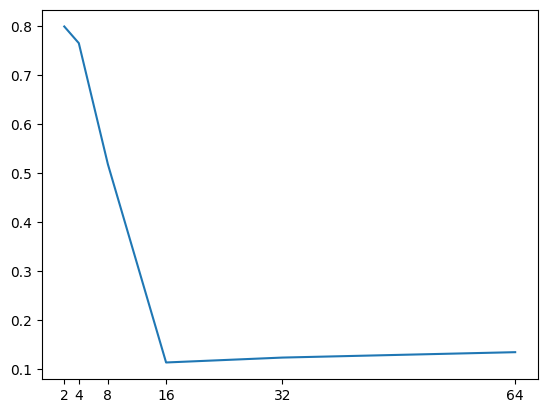

In [15]:
plot_performance_multiple_models([2, 4, 8, 16, 32, 64], test_acc)

Let's try a simple trick to try to improve our performance when the network becomes deeper: residual connections. Modify the GNN class to allow an option for adding residual connections and then rerun the previous experiments, this time using residual connections for each layer.

In [17]:
test_acc = []
for num_layers in [2, 4, 8, 16, 32, 64]:
    print(f"Training a network with {num_layers} GCN layers")
    model = GNN(dataset.num_features, HIDDEN_CHANNELS, dataset.num_classes, num_layers, DROPOUT_RATE, residual=True)
    model.to(DEVICE)
    acc = run_experiment(model, dataset)
    test_acc.append(acc.item())
    print(f"Test accuracy: {acc}")
    print("---------------------------------------------------")

Training a network with 2 GCN layers
Epoch: 0, Loss: 1.9419
Epoch: 1, Loss: 1.9124
Epoch: 2, Loss: 1.8772
Epoch: 3, Loss: 1.8424
Epoch: 4, Loss: 1.8060
Epoch: 5, Loss: 1.7696
Epoch: 6, Loss: 1.7207
Epoch: 7, Loss: 1.6646
Epoch: 8, Loss: 1.6067
Epoch: 9, Loss: 1.5454
Epoch: 10, Loss: 1.4648
Epoch: 11, Loss: 1.4025
Epoch: 12, Loss: 1.3172
Epoch: 13, Loss: 1.2284
Epoch: 14, Loss: 1.1319
Epoch: 15, Loss: 1.0231
Epoch: 16, Loss: 0.9312
Epoch: 17, Loss: 0.8126
Epoch: 18, Loss: 0.7215
Epoch: 19, Loss: 0.6178
Epoch: 20, Loss: 0.5284
Epoch: 21, Loss: 0.4689
Epoch: 22, Loss: 0.3766
Epoch: 23, Loss: 0.3324
Epoch: 24, Loss: 0.2582
Epoch: 25, Loss: 0.2090
Epoch: 26, Loss: 0.1626
Epoch: 27, Loss: 0.1435
Epoch: 28, Loss: 0.1097
Epoch: 29, Loss: 0.0871
Epoch: 30, Loss: 0.0700
Epoch: 31, Loss: 0.0581
Epoch: 32, Loss: 0.0490
Epoch: 33, Loss: 0.0354
Epoch: 34, Loss: 0.0317
Epoch: 35, Loss: 0.0237
Epoch: 36, Loss: 0.0182
Epoch: 37, Loss: 0.0192
Epoch: 38, Loss: 0.0131
Epoch: 39, Loss: 0.0114
Epoch: 40, Lo

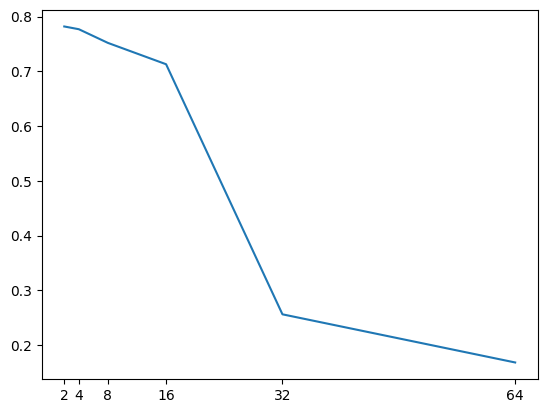

In [18]:
plot_performance_multiple_models([2, 4, 8, 16, 32, 64], test_acc)

Now, let's see the behavior of a different convolution that we discussed about during the theoretical session, GCNII, which uses *Initial residual* and *Identity mapping* transformations. Luckily, this convolution is implemented in Pytorch Geometric [too](https://pytorch-geometric.readthedocs.io/en/2.6.0/generated/torch_geometric.nn.conv.GCN2Conv.html#torch_geometric.nn.conv.GCN2Conv). Check the documentation carefully, this convolution requires additional hyper-parameters and the forward call will look different too. Try first to set alpha=0.1 and theta=0.5, then vary these parameters and see how this impacts the performance.

In [31]:
# GCNII
import math
from torch_geometric.nn import GCN2Conv

class GCNII(torch.nn.Module):
    def __init__(self, input_channels, hidden_channels,
                 num_outputs, num_layers, dropout_rate,
                 alpha, theta):
        super().__init__()

        self.initial_layer = Linear(input_channels, hidden_channels)

        self.conv_layers = ModuleList()
        for i in range(num_layers):
            self.conv_layers.extend([
                GCN2Conv(hidden_channels, alpha=alpha, theta=theta, layer=i+1),
                ReLU(),
                Dropout(dropout_rate)
            ])

        self.final_layer = Linear(hidden_channels, num_outputs)

    def forward(self, x, edge_index):
        h0 = F.relu(self.initial_layer(x))
        x = h0

        for layer in self.conv_layers:
            if isinstance(layer, MessagePassing):
                # this layer requires the initial node embeddings too, since
                # they are added to the node representations obtained from the
                # current layer; we use the transformed representation, h0, not
                # the original features, because the shapes need to be identical
                x = layer(x, h0, edge_index)
            else:
                x = layer(x)
        return self.final_layer(x)

In [32]:
test_acc = []
for num_layers in [2, 4, 8, 16, 32, 64]:
    print(f"Training a network with {num_layers} GCNII layers")
    model = GCNII(dataset.num_features, HIDDEN_CHANNELS, dataset.num_classes, num_layers, DROPOUT_RATE, alpha=0.1, theta=0.5)
    model.to(DEVICE)
    acc = run_experiment(model, dataset)
    test_acc.append(acc.item())
    print(f"Test accuracy: {acc}")
    print("---------------------------------------------------")

Training a network with 2 GCNII layers
Epoch: 0, Loss: 1.9466
Epoch: 1, Loss: 1.9363
Epoch: 2, Loss: 1.9269
Epoch: 3, Loss: 1.9163
Epoch: 4, Loss: 1.9055
Epoch: 5, Loss: 1.8939
Epoch: 6, Loss: 1.8802
Epoch: 7, Loss: 1.8660
Epoch: 8, Loss: 1.8491
Epoch: 9, Loss: 1.8285
Epoch: 10, Loss: 1.8073
Epoch: 11, Loss: 1.7831
Epoch: 12, Loss: 1.7588
Epoch: 13, Loss: 1.7308
Epoch: 14, Loss: 1.6991
Epoch: 15, Loss: 1.6645
Epoch: 16, Loss: 1.6335
Epoch: 17, Loss: 1.5956
Epoch: 18, Loss: 1.5519
Epoch: 19, Loss: 1.5088
Epoch: 20, Loss: 1.4565
Epoch: 21, Loss: 1.4162
Epoch: 22, Loss: 1.3595
Epoch: 23, Loss: 1.3078
Epoch: 24, Loss: 1.2564
Epoch: 25, Loss: 1.1937
Epoch: 26, Loss: 1.1303
Epoch: 27, Loss: 1.0835
Epoch: 28, Loss: 1.0136
Epoch: 29, Loss: 0.9360
Epoch: 30, Loss: 0.8912
Epoch: 31, Loss: 0.8291
Epoch: 32, Loss: 0.7546
Epoch: 33, Loss: 0.6993
Epoch: 34, Loss: 0.6399
Epoch: 35, Loss: 0.5958
Epoch: 36, Loss: 0.5403
Epoch: 37, Loss: 0.4838
Epoch: 38, Loss: 0.4355
Epoch: 39, Loss: 0.3936
Epoch: 40, 

Let's plot the performance over the different number of layers. Does this network behave differently from the other ones?

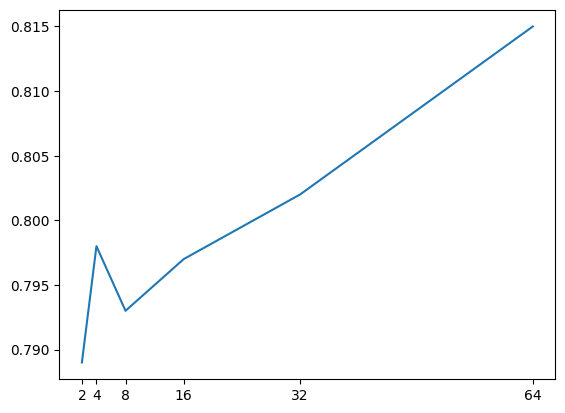

In [33]:
plot_performance_multiple_models([2, 4, 8, 16, 32, 64], test_acc)

Bibliography:


1.   [Pytorch Geometric Node classification tutorial](https://pytorch-geometric.readthedocs.io/en/2.6.1/get_started/colabs.html)
2.   [Uv A GNN tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial7/GNN_overview.html)
3. [Hands-on Graph Neural Networks with PyTorch Geometric (1): Cora Dataset](https://medium.com/@koki_noda/ultimate-guide-to-graph-neural-networks-1-cora-dataset-37338c04fe6f)
4. [EEML summer school GNN tutorial](https://github.com/eemlcommunity/PracticalSessions2024/tree/main/4_geometric_deep_learning)
